<a href="https://colab.research.google.com/github/SHREY1305/Dissertation-Artefact/blob/main/Shreyash_Chavan_20062676_Artefact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 1 - CRISIL Scraping**

# Install Required Libraries

# Import Libraries

In [ ]:
# requests visits websites and downloads their content
import requests
# BeautifulSoup reads website content and finds specific data inside it
from bs4 import BeautifulSoup
# pandas lets us create and work with tables of data like Excel
import pandas as pd
# datetime lets us work with calendar dates
from datetime import datetime
# time lets us pause our code for a few seconds
import time

# Define Website URLs and Date Ranges

In [ ]:
# Crisil has two historical pages used in this study
# One page covers FY2023, one covers FY2024

PAGES = {'FY2023': {'url':'https://www.crisilesg.com/en/home/esg-ratings/historical-ratings/esg-ratings-2023.html'},
'FY2024': {'url':'https://www.crisilesg.com/en/home/esg-ratings/historical-ratings/esg-ratings-2024.html'}}

# Extract ESG Score

In [ ]:
# Create a function called score_number
# This function takes one input called "text"
# The input will contain the ESG score information from CRISIL

def get_score_number(text):
  # If there is no text, return nothing
  if not text:
    return None

  # Convert the value into text
  # This ensures the function works even if the input is not already text
  text = str(text)

  # CRISIL sometimes shows ratings as "Withdrawn"
  # Ignore withdrawn ratings
  if "withdrawn" in text.lower():
      return None

  # Split the text into words
  # "Crisil ESG 62" becomes ["Crisil", "ESG", "62"]
  words = text.split()

  # Check each individual word one by one
  for word in words:
    # Check whether the word contains only numbers
    if word.isdigit():
    # Convert the text number into an integer
      score = int(word)

      # Check if it is a valid ESG score
      if 0 <= score <= 100:
            return score

    # No valid score found in any word
  return None

The function was created to extract numerical ESG scores from the text collected from the CRISIL website.

# Convert CRISIL Rating Dates into Python Date Format

In [ ]:
# Created a function called get_date
# This function takes one input called 'text'. the input will contain the rating date collected from CRISIL
def get_date(text):
    # Remove any extra spaces around the text
  text = str(text).strip()
  # Try converting the date format:
  # Day-Month-2 digit year for example 17-Jul-24
  try:
      return datetime.strptime(text, '%d-%b-%y')
  except:
        # If that did not work, try this format # Day-Month-4 digit year
    try:
        return datetime.strptime(text, '%d-%b-%Y')
    except:
            # If neither worked, give back nothing
        return None
 # Testing it worked
test_date = get_date('17-Jul-24')
print(f"17-Jul-24 became {test_date}")

17-Jul-24 became 2024-07-17 00:00:00


The function was created to convert CRISIL rating dates from text format into Python datetime format.

# Scrape CRISIL Website

In [ ]:
def scrape_crisil_page(url, fy_label):

    # Download webpage from CRISIL
  headers = {"User-Agent": "Mozilla/5.0"}
  response = requests.get(url,headers=headers)

    # Convert webpage HTML into readable format
  soup = BeautifulSoup(response.content,"lxml")

    # Find all tables on webpage
  tables = soup.find_all("table")

    # Empty list to store company information
  records = []

    # Helper function to find column index
  def find_column(headers, keyword):
      # Loop through each header and its index number
      for i, header in enumerate(headers):
           # Convert both to lowercase to ensure a match
          # (e.g., "ESG Score" matches "esg")
          if keyword.lower() in header.lower():
              return i
        # If the keyword isn't found in any header, return None
      return None

    # Check every table
  for table in tables:
        # Get all rows from table
      rows = table.find_all("tr")

        # Skip empty tables
      if len(rows) == 0:
          continue

        # Read table header
      headers_row = []
      for header in rows[0].find_all(["th", "td"]):
          headers_row.append(header.get_text(strip=True))

        # Find column positions
      company_col = find_column(headers_row,"company")

        # Some pages may use issuer instead of company
      if company_col is None:
        company_col = find_column(headers_row,"issuer")

      sector_col = find_column(headers_row,"sector")
      score_col = find_column(headers_row,"esg")
      category_col = find_column(headers_row,"category")
      date_col = find_column(headers_row,"date")

        # If important columns are missing,
        # ignore this table
      if (company_col is None or score_col is None or date_col is None):
          continue

        # Read company data
      for row in rows[1:]:
          cells = []
          # Extract each cell value
          for cell in row.find_all(["td", "th"]):
              cells.append(cell.get_text(strip=True))

            # Ignore empty rows
          if len(cells) == 0:
              continue
          # Prevent index errors
          if (company_col >= len(cells) or score_col >= len(cells) or date_col >= len(cells)):
              continue

            # Get company name
          company = cells[company_col]

            # Get ESG score text
          score_text = cells[score_col]

            # Get rating date
          date_text = cells[date_col]

            # Get sector if available
          if sector_col is not None and sector_col < len(cells):
              sector = cells[sector_col]
          else:
              sector = None

            # Get category if available
          if category_col is not None and category_col < len(cells):
              category = cells[category_col]
          else:
              category = None

            # Convert ESG score into number
          score = get_score_number(score_text)

            # Convert date into Python date
          rating_date = get_date(date_text)

          if score is None or rating_date is None: #If we couldn't find a valid ESG score, or if we couldn't find a valid date, skip this row and move on to the next company.
                continue

            # Store company information
          records.append({"company_name": company,"sector": sector,"esg_score": score,"category": category,
                "date_of_rating": date_text,"rating_date": rating_date,"financial_year": fy_label})

    # Convert list into dataframe
  df = pd.DataFrame(records)

  return df

This function automated the collection of ESG rating data from the CRISIL webpages.

# Run the Scraper for FY2023, FY2024

In [ ]:

# Create an empty dictionary to store the data for each financial year
# Each financial year will have its own dataframe
all_data = {}

# read (Loop) through every financial year stored in PAGES
for year in PAGES:
    # Get the information (URL and dates) for this year
  page = PAGES[year]

  # Scrape the data from the website, Main scraping starts
  data = scrape_crisil_page(page["url"], year)

    # Store the collected dataframe inside all_data
  all_data[year] = data

    # Wait 3 seconds before visiting the next page
  time.sleep(3) # This avoids sending many requests to the website quickly

# Show how many companies were collected
print("Summary")

# Display the number of companies collected for each financial year
for year in all_data:
    print(year, ":", len(all_data[year]), "companies")

Summary
FY2023 : 983 companies
FY2024 : 1044 companies


This cell runs the scraper for each CRISIL financial year page saves each years ESG data separately waits between requests and finally shows how many companies were collected from each year.

# Remove Duplicate Companies

In [ ]:
# This function keeps only the latest ESG rating for each company
def remove_duplicates(df, year):

    # If there is no data, return the empty table
  if df.empty:
      return df

    # Create a new column with cleaned company names
  df["name_clean"] = df["company_name"]
    # Remove spaces before and after the company name
  df["name_clean"] = df["name_clean"].str.strip()
    # Change all letters to uppercase
  df["name_clean"] = df["name_clean"].str.upper()
      # (e.g. "THE FEDERAL BANK LIMITED" becomes "FEDERAL BANK LIMITED")
  df["name_clean"] = df["name_clean"].str.replace(r"^THE ", "", regex=True)
    # Replace "AND" with "&" so names match NSE's official format
  df["name_clean"] = df["name_clean"].str.replace(" AND ", " & ", regex=False)
  # Change LTD to LIMITED
  df["name_clean"] = df["name_clean"].str.replace(" LTD."," LIMITED",regex=False)
  # Change CO to COMPANY
  df["name_clean"] = df["name_clean"].str.replace(" CO."," COMPANY",regex=False)
  # Change MFG to MANUFACTURING
  df["name_clean"] = df["name_clean"].str.replace(" MFG."," MANUFACTURING",regex=False)
    # Remove punctuation and brackets
  df["name_clean"] = (df["name_clean"].str.replace(".", " ", regex=False).str.replace(",", " ", regex=False).str.replace("(", " ", regex=False).str.replace(")", " ", regex=False).str.replace("-", " ", regex=False).str.replace("/", " ", regex=False).str.replace("'", " ", regex=False))
    # Remove repeated spaces between words
  df["name_clean"] = (df["name_clean"].str.split().str.join(" "))

    # Sort by company name and then by rating date
    # The newest rating will appear first for each company
  df = df.sort_values(by=["company_name", "rating_date"],ascending=[True, False])

    # Remove duplicate companies
    # If the same company appears multiple times, keep the first row because it has the latest rating date
  df = df.drop_duplicates(subset="name_clean", keep="first")

  print(year,":", len(df),"unique companies")
  return df

# Create an empty dictionary to store the cleaned data
clean_data = {}
# Clean each financial year's data
for year in all_data:
    data = all_data[year]
# Remove duplicates
    cleaned = remove_duplicates(data,year)
# Store the cleaned dataframe
    clean_data[year] = cleaned

print("Duplicate companies removed.")

FY2023 : 982 unique companies
FY2024 : 976 unique companies
Duplicate companies removed.


Duplicate observations were removed by sorting companies according to their rating date and retaining the latest ESG rating for each company within each financial year. This ensured that each company had only one ESG observation per year.

# Combine All Financial Years

In [ ]:
# Create an empty list to store each year's table
all_tables = []
# Go through each financial year one by one
for year in clean_data:
    # Get the table for this year
  data = clean_data[year]
    # Check if the dataframe contains data
    # If it is not empty, add it to our list
  if not data.empty:
      all_tables.append(data)

# Combine all the tables into one large table
panel = pd.concat(all_tables, ignore_index=True)

# Show a summary
print("Total rows:", len(panel))
print("Companies in each financial year:")
print(panel["financial_year"].value_counts())

Total rows: 1958
Companies in each financial year:
financial_year
FY2023    982
FY2024    976
Name: count, dtype: int64


In [ ]:
# Verify rating dates support the FY-to-fiscal-year mapping assumption
panel["rating_date"] = pd.to_datetime(panel["rating_date"])
rating_date_summary = panel.groupby("financial_year")["rating_date"].agg(["min", "median", "max"])
print(rating_date_summary)

                      min     median        max
financial_year                                 
FY2023         2024-05-03 2024-07-03 2024-11-08
FY2024         2024-11-21 2025-04-02 2025-06-02


FY2023 ratings were issued after 31 March 2024. Some FY2024 ratings were issued before 31 March 2025.

In [ ]:
# Save the combined table
panel.to_csv("crisil_esg_panel.csv", index=False)

# **Section 2 — NSE Ticker Matching**

# Import Required Libraries

In [ ]:
# pandas helps us work with tables of data
from pandas import read_csv
# requests helps us download data from the internet
import requests

panel = read_csv('/content/crisil_esg_panel.csv')

# Load CRISIL ESG Dataset



In [ ]:
# Count how many financial years each company appears in
company_count = panel.groupby("name_clean")["financial_year"].nunique()

# Keep only companies that appear in all both financial years
companies = company_count[company_count == 2].index

# Create a new table with only these companies
balanced_data = panel[panel["name_clean"].isin(companies)]

# Show the results
print("Total rows:", len(balanced_data))
print("Total companies:", balanced_data["name_clean"].nunique())

Total rows: 1898
Total companies: 949


The purpose is to ensure that the same companies are observed consistently over the two year period.


# Create Unique Company List for Ticker Matching

In [ ]:
# Keep only one row per company because ticker matching is done once per company
unique_companies = balanced_data.drop_duplicates(subset="name_clean").copy()

print("Unique companies:", len(unique_companies))

Unique companies: 949


# Read NSE Company Data downlaoded on 12th August 2026

### Upload the NSE eqity dataset here.

In [ ]:
# Read NSE CSV file into pandas dataframe
nse_data = read_csv("/content/drive/MyDrive/2 Years estimation dataset/Shreyash_chavan_dataset_nse_companies-12 August 2026.csv")

# Check number of companies downloaded
print("Total NSE companies:", len(nse_data))

Total NSE companies: 2404


The NSE company master file was downloaded on 12 August 2026 and saved in Google Drive. The CSV file was then loaded into pandas for ticker matching and further processing.

# Keep Only NSE Equity Companies

In [ ]:
# Cell: Keep Only NSE Equity Companies

# Clean column names to avoid errors due to extra spaces or different capital letters
nse_data.columns = nse_data.columns.str.strip().str.upper()


# Keep only normal equity companies from NSE data
nse_eq = nse_data[nse_data["SERIES"] == "EQ"].copy()


# Check number of equity companies
print("Total NSE equity companies:", len(nse_eq))


# Display first 5 companies
nse_eq.head()

Total NSE equity companies: 2125


,SYMBOL,NAME OF COMPANY,SERIES,DATE OF LISTING,PAID UP VALUE,MARKET LOT,ISIN NUMBER,FACE VALUE
0,20MICRONS,20 Microns Limited,EQ,06-OCT-2008,5,1,INE144J01027,5
1,21STCENMGM,21st Century Management Services Limited,EQ,03-MAY-1995,10,1,INE253B01015,10
2,360ONE,360 ONE WAM LIMITED,EQ,19-SEP-2019,1,1,INE466L01038,1
3,3BBLACKBIO,3B Blackbio Dx Limited,EQ,20-APR-2026,10,1,INE994E01018,10
4,3IINFOLTD,3i Infotech Limited,EQ,22-OCT-2021,10,1,INE748C01038,10


# Clean NSE company names

In [ ]:
# Create a cleaned company name column
nse_eq["name_clean"] = nse_eq["NAME OF COMPANY"]

# Remove extra spaces at the beginning and end
nse_eq["name_clean"] = nse_eq["name_clean"].str.strip()

# Convert all company names to uppercase
nse_eq["name_clean"] = nse_eq["name_clean"].str.upper()

      # (e.g. "THE FEDERAL BANK LIMITED" becomes "FEDERAL BANK LIMITED")
nse_eq["name_clean"] = nse_eq["name_clean"].str.replace(r"^THE ", "", regex=True)

# Replace "AND" with "&" so names match NSE's official format
nse_eq["name_clean"] = nse_eq["name_clean"].str.replace(" AND ", " & ", regex=False)

# Change LTD to LIMITED
nse_eq["name_clean"] = nse_eq["name_clean"].str.replace(" LTD."," LIMITED",regex=False)

  # Change CO to COMPANY
nse_eq["name_clean"] = nse_eq["name_clean"].str.replace(" CO."," COMPANY",regex=False)

nse_eq["name_clean"] = nse_eq["name_clean"].str.replace("*"," ",regex=False)

  # Change MFG to MANUFACTURING
nse_eq["name_clean"] = nse_eq["name_clean"].str.replace(" MFG."," MANUFACTURING",regex=False)

    # Remove punctuation and brackets
nse_eq["name_clean"] = (nse_eq["name_clean"].str.replace(".", " ", regex=False).str.replace(",", " ", regex=False).str.replace("(", " ", regex=False).str.replace(")", " ", regex=False).str.replace("-", " ", regex=False).str.replace("/", " ", regex=False).str.replace("'", " ", regex=False))

    # Remove repeated spaces between words
nse_eq["name_clean"] = (nse_eq["name_clean"].str.split().str.join(" "))

# Display first 5 cleaned company names
nse_eq[["NAME OF COMPANY", "name_clean"]].head()


,NAME OF COMPANY,name_clean
0,20 Microns Limited,20 MICRONS LIMITED
1,21st Century Management Services Limited,21ST CENTURY MANAGEMENT SERVICES LIMITED
2,360 ONE WAM LIMITED,360 ONE WAM LIMITED
3,3B Blackbio Dx Limited,3B BLACKBIO DX LIMITED
4,3i Infotech Limited,3I INFOTECH LIMITED


This cell prepares the NSE company names for matching with the CRISIL dataset.

# Match Companies to Ticker Symbols

In [ ]:
# First, we DEFINE the function
def add_ticker_symbols(crisil_data, nse_data):

    # Create the lookup dictionary mapping NSE names to their SYMBOL
  nse_dictionary = dict(zip(nse_data["name_clean"], nse_data["SYMBOL"]))

    # Make a copy so we don't accidentally mess up our original data
  updated_data = crisil_data.copy()

    # Add a new column using our dictionary
  updated_data["ticker"] = updated_data["name_clean"].map(nse_dictionary)

    # Count successes and failures
  successful = updated_data["ticker"].notna().sum()
  failed = updated_data["ticker"].isna().sum()

    # Print the report
  print(f"Successfully matched: {successful} companies")
  print(f"Failed to match: {failed} companies")

  return updated_data

# Now, we USE the function we just created
unique_companies = add_ticker_symbols(unique_companies, nse_eq)

Successfully matched: 837 companies
Failed to match: 112 companies


# Checking the failed ticker

In [ ]:
# 1. Filter out the companies that have an empty (NaN) ticker
missing = unique_companies[unique_companies["ticker"].isna()]

# 2. Convert that column to a simple list and print it all at once
print(missing["name_clean"].tolist())

['AGS TRANSACT TECHNOLOGIES LIMITED', 'ADITYA BIRLA HOUSING FINANCE LIMITED', 'AKZO NOBEL INDIA LIMITED', 'ALLCARGO GATI LIMITED', 'ASTER DM HEALTHCARE LIMITED', 'AXIS FINANCE LIMITED', 'BAHADUR CHAND INVESTMENTS PRIVATE LIMITED', 'BARBEQUE NATION HOSPITALITY LIMITED', 'BERGER PAINTS INDIA LIMITED', 'BHARTI TELECOM LIMITED', 'BIRLA GROUP HOLDINGS PRIVATE LIMITED', 'BLISS GVS PHARMA LIMITED', 'BODAL CHEMICALS LIMITED', 'BOMBAY DYEING & MANUFACTURING COMPANY LIMITED', 'BROOKFIELD INDIA REAL ESTATE TRUST', 'CHEMCON SPECIALITY CHEMICALS LIMITED', 'DHANI SERVICES LIMITED', 'EXIM BANK', 'EDELWEISS RURAL & CORPORATE SERVICES LIMITED', 'EMAMI PAPER MILLS LIMITED', 'EMBASSY OFFICE PARKS REIT', 'EVEREST INDUSTRIES LIMITED', 'FOOD CORPORATION OF INDIA', 'FORCE MOTORS LIMITED', 'GANESH HOUSING CORPORATION LIMITED', 'GLAXO SMITHKLINE PHARMACEUTICALS LIMITED', 'GUJARAT GAS LIMITED', 'GUJARAT STATE PETRONET LIMITED', 'HDFC SECURITIES LIMITED', 'HLE GLASSCOAT LIMITED', 'HMT LIMITED', 'HEIDELBERG CEMEN

In [ ]:
# Complete Manual Mapping and Prepare for Yahoo Finance

# 1. The complete override dictionary for the listed companies
manual_dictionary = {"AKZO NOBEL INDIA LIMITED": "JSWDULUX",
    "ASTER DM HEALTHCARE LIMITED": "ASTERDM",
    "BERGER PAINTS INDIA LIMITED": "BERGEPAINT",
    "BOMBAY DYEING & MANUFACTURING COMPANY LIMITED": "BOMDYEING",
    "FORCE MOTORS LIMITED": "FORCEMOT",
    "GANESH HOUSING CORPORATION LIMITED": "GANESHHOU",
    "GLAXO SMITHKLINE PHARMACEUTICALS LIMITED": "GLAXO",
    "GUJARAT GAS LIMITED": "GUJENERGY",
    "HLE GLASSCOAT LIMITED": "HLEGLAS",
    "HEIDELBERG CEMENT INDIA LIMITED": "HEIDELBERG",
    "ITD CEMENTATION INDIA LIMITED": "CEMPRO",
    "INFIBEAM AVENUES LIMITED": "CCAVENUE",
    "JINDAL STEEL & POWER LIMITED": "JINDALSTEL",
    "JOHNSON CONTROLS HITACHI AIR CONDITIONING INDIA LIMITED": "BOSCH-HCIL",
    "KFIN TECHNOLOGIES PRIVATE LIMITED": "KFINTECH",
    "L G BALAKRISHNAN & BROS LIMITED": "LGBBROSLTD",
    "LA OPALA R G LIMITED": "LAOPALA",
    "LTIMINDTREE LIMITED": "LTM",
    "MACROTECH DEVELOPERS LIMITED": "LODHA",
    "MAYUR UNIQUOTERS LIMITED": "MAYURUNIQ",
    "NRB BEARINGS LIMITED": "NRBBEARING",
    "PIRAMAL ENTERPRISES LIMITED": "PIRAMALFIN",
    "RADIANT CASH MANAGEMENT SERVICES PRIVATE LIMITED": "RADIANTCMS",
    "SAVITA OIL TECHNOLOGIES LTD": "SOTL",
    "SEQUENT SCIENTIFIC LIMITED": "VIYASH",
    "SUNFLAG IRON & STEEL COMPANYLIMITED": "SUNFLAG",
    "SWAN ENERGY LIMITED": "SWANCORP",
    "T V TODAY NETWORK LIMITED": "TVTODAY",
    "TAJ G V K HOTELS & RESORTS LIMITED": "TAJGVK",
    "VENKYS INDIA LIMITED": "VENKEYS",
    "VIMTA LABORATORIES LIMITED": "VIMTALABS"}

# apply the dictionary to the missing rows
manual_tickers = unique_companies["name_clean"].map(manual_dictionary)
unique_companies["ticker"] = unique_companies["ticker"].fillna(manual_tickers)

# We drop any row where 'ticker' is still NaN (missing)
final_companies = unique_companies.dropna(subset=['ticker']).copy()

# Format everything for Yahoo Finance by appending ".NS"
final_companies["yfinance_ticker"] = final_companies["ticker"] + ".NS"


In [ ]:
print("Total companies kept:", len(final_companies))
print("Companies still without ticker:",unique_companies["ticker"].isna().sum())

final_companies[["name_clean", "ticker", "yfinance_ticker"]].head()

Total companies kept: 868
Companies still without ticker: 81


,name_clean,ticker,yfinance_ticker
0,360 ONE WAM LIMITED,360ONE,360ONE.NS
1,3M INDIA LIMITED,3MINDIA,3MINDIA.NS
2,AAVAS FINANCIERS LIMITED,AAVAS,AAVAS.NS
3,ABB INDIA LIMITED,ABB,ABB.NS
4,ACC LIMITED,ACC,ACC.NS


After the automatic matching process 112 company names were still unmatched because the company names were written differently in the CRISIL and NSE datasets.

In [ ]:
print("Total companies:", len(final_companies))

Total companies: 868


# Merging with the ESG dataset and tickers

In [ ]:
def attach_tickers(main_data, ticker_data):
    # 1. Create the lookup dictionary from our clean ticker data
  ticker_dictionary = dict(zip(ticker_data["name_clean"], ticker_data["yfinance_ticker"]))

    # 2. Make a safe copy of the main dataset
  merged_data = main_data.copy()

    # 3. Use .map() to look up and attach the tickers
  merged_data["yfinance_ticker"] = merged_data["name_clean"].map(ticker_dictionary)

    # 4. Drop unlisted companies that couldn't get a ticker
  final_clean_data = merged_data.dropna(subset=["yfinance_ticker"])

  return final_clean_data

# Use the function
esg_panel_ready = attach_tickers(balanced_data, final_companies)

In [ ]:
print("Total rows:", len(esg_panel_ready))
print("Total companies:", esg_panel_ready["name_clean"].nunique())

Total rows: 1736
Total companies: 868


# Final Data Cleaning Removing Financial and Holding Companies

In [ ]:
# Create a list of all the financial sectors you want to drop
financial_sectors = ['Asset Management Company','Bank','Banks','Financial Institution','Financial Institutions','Financial Products Distributor','Financial Services (Capital Market)','Financial Services (capital markets)','Financial Services (fintech)',
    'Financial Services (others)','Financial Technology (Fintech)','Financial services (Asset Management Company)','General Insurance','Housing Finance Company','IT – Financial Technology','Information Technology - Financial Technology (Fintech)','Insurance','Investment Company',
    'Life Insurance','Microfinance Institutions','NBFC','Non Banking Financial Company (NBFC)','Other Bank','Other Financial Services','Private Sector Bank','Public Sector Bank','REIT','Stockbroking & Allied']

We are estimating ESG scores based on financial indicators. Banks and financial institutions have completely different capital structures and accounting rules compared to regular companies.



In [ ]:
# Identify ALL companies that ever touch a financial sector in any year
financial_companies = esg_panel_ready['sector'].isin(financial_sectors)
companies_to_drop = esg_panel_ready[financial_companies]['name_clean'].unique()

# Drop the entire company all 2 years using False
esg_panel_no_fin = esg_panel_ready[esg_panel_ready['name_clean'].isin(companies_to_drop) == False].copy()

# Dynamic Holding Company Drop, Find any row where the sector contains the word holding
holding_company = esg_panel_no_fin['sector'].str.contains('holding', case=False, na=False)

# Grab the unique names of those companies so we drop them across all 2 years
holding_companies_to_drop = esg_panel_no_fin[holding_company]['name_clean'].unique()

# Drop holding companies entirely using == False
final_clean_panel = esg_panel_no_fin[esg_panel_no_fin['name_clean'].isin(holding_companies_to_drop) == False].copy()

# Handle exact entry duplicates
final_clean_panel = final_clean_panel.drop_duplicates(subset=['name_clean', 'financial_year'], keep='first')

print("Total rows:", len(final_clean_panel))
print("Total companies:", final_clean_panel['name_clean'].nunique())

Total rows: 1496
Total companies: 748


In [ ]:
final_clean_panel.to_csv("final_clean_esg_panel.csv", index=False)

# **Section 3 - Yahoo Finance and financial data collection**

In [ ]:
import yfinance as yf
import numpy as np

clean_panel = read_csv("/content/final_clean_esg_panel.csv")

# Financial Data Extraction & Calculation

In [ ]:
  # Step 1: Create an empty list to store the results

financial_results = []

# Get unique Yahoo Finance tickers

unique_tickers = clean_panel["yfinance_ticker"].dropna().unique()

# Match Yahoo statement dates with your CRISIL financial-year labels

year_mapping = {pd.Timestamp("2024-03-31"): "FY2023",pd.Timestamp("2025-03-31"): "FY2024"}

# Function to safely find a financial value

def find_number(statement, row_name, date):

    if row_name in statement.index and date in statement.columns:
        value = statement.loc[row_name, date]

        if pd.notna(value):
            return value
    return np.nan


# Step 2: Download financial data for every company

for ticker in unique_tickers:

    try:
        stock = yf.Ticker(ticker)

        income_statement = stock.financials
        balance_sheet = stock.balance_sheet

        # Skip the company if its statements are unavailable

        if income_statement.empty or balance_sheet.empty:
            print("Statements unavailable:", ticker)
            continue

        # Only process the two required statement dates

        for date, financial_year in year_mapping.items():

            # Check that the date exists in both statements

            if (date not in income_statement.columns
                or date not in balance_sheet.columns):
                print("Required date unavailable:", ticker, date.date())
                continue

            # Extract the required financial values
            net_income = find_number(income_statement,"Net Income",date)

            total_revenue = find_number(income_statement,"Total Revenue",date)

            total_assets = find_number(balance_sheet,"Total Assets",date)

            # Get shareholders' equity
            # Try the primary equity field first
            total_equity = find_number(balance_sheet,"Stockholders Equity",date)

            if pd.notna(total_equity):
                equity_source = "Stockholders Equity"
            else:
                # Use the alternative field if the primary field is missing
                total_equity = find_number(balance_sheet,"Total Equity Gross Minority Interest",date)
                if pd.notna(total_equity):
                    equity_source = ("Total Equity Gross Minority Interest")
                else:
                    equity_source = "Missing"


            # Get Total Debt
            # Try the primary Total Debt field first
            total_debt = find_number(balance_sheet,"Total Debt",date)

            if pd.notna(total_debt):
                debt_source = "Total Debt"
            else:
                # Try to calculate debt using current and long-term debt
                current_debt = find_number(balance_sheet,"Current Debt",date)

                long_term_debt = find_number(balance_sheet,"Long Term Debt",date)

                if (pd.notna(current_debt)and pd.notna(long_term_debt)):
                    total_debt = current_debt + long_term_debt
                    debt_source = ("Current Debt + Long Term Debt")
                else:
                    total_debt = np.nan
                    debt_source = "Missing"
            # Calculate the financial indicators

            ROA = (net_income / total_assets
                if pd.notna(net_income)
                and pd.notna(total_assets)
                and total_assets != 0
                else np.nan)

            ROE = (net_income / total_equity
                if pd.notna(net_income)
                and pd.notna(total_equity)
                and total_equity != 0
                else np.nan)

            Debt_to_Equity = (total_debt / total_equity
                if pd.notna(total_debt)
                and pd.notna(total_equity)
                and total_equity != 0
                else np.nan)

            Firm_Size = (np.log(total_assets)
                if pd.notna(total_assets)
                and total_assets > 0
                else np.nan)

            Leverage = (total_debt / total_assets
                if pd.notna(total_debt)
                and pd.notna(total_assets)
                and total_assets != 0
                else np.nan)

            Net_Profit_Margin = (net_income / total_revenue
                if pd.notna(net_income)
                and pd.notna(total_revenue)
                and total_revenue != 0
                else np.nan)

            # Store raw values and calculated indicators

            financial_results.append({"yfinance_ticker": ticker,"financial_year": financial_year,
                                      "actual_statement_date": date,"Net_Income": net_income,
                                      "Total_Revenue": total_revenue,"Total_Assets": total_assets,
                                      "Total_Equity": total_equity,"Total_Debt": total_debt,
                                      "ROA": ROA,"ROE": ROE,
                                      "Debt_to_Equity": Debt_to_Equity,"Firm_Size": Firm_Size,
                                      "Leverage": Leverage,"Net_Profit_Margin": Net_Profit_Margin,
                                      "equity_source": equity_source,"debt_source": debt_source}) # Add debt_source here

    except Exception as e:
        print("Error:", ticker, "-", e)


# Step 3: Convert the results into a DataFrame
financial_data = pd.DataFrame(financial_results)

print("Financial records collected:", len(financial_data))
print("Companies collected:", financial_data["yfinance_ticker"].nunique())

financial_data.head()

Required date unavailable: ABB.NS 2024-03-31
Required date unavailable: ABB.NS 2025-03-31
Required date unavailable: ACCELYA.NS 2024-03-31
Required date unavailable: ACCELYA.NS 2025-03-31
Required date unavailable: CIEINDIA.NS 2024-03-31
Required date unavailable: CIEINDIA.NS 2025-03-31
Required date unavailable: CASTROLIND.NS 2024-03-31
Required date unavailable: CASTROLIND.NS 2025-03-31
Statements unavailable: DISAQ.NS
Required date unavailable: ELANTAS.NS 2024-03-31
Required date unavailable: ELANTAS.NS 2025-03-31
Required date unavailable: GILLETTE.NS 2024-03-31
Required date unavailable: GILLETTE.NS 2025-03-31
Required date unavailable: HUHTAMAKI.NS 2024-03-31
Required date unavailable: HUHTAMAKI.NS 2025-03-31
Required date unavailable: KSB.NS 2024-03-31
Required date unavailable: KSB.NS 2025-03-31
Required date unavailable: KENNAMET.NS 2024-03-31
Required date unavailable: KENNAMET.NS 2025-03-31
Required date unavailable: NESTLEIND.NS 2024-03-31
Required date unavailable: PGHL.NS

,yfinance_ticker,financial_year,actual_statement_date,Net_Income,Total_Revenue,Total_Assets,Total_Equity,Total_Debt,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin,equity_source,debt_source
0,3MINDIA.NS,FY2023,2024-03-31,5.834168e+09,4.186874e+10,3.248224e+10,2.146903e+10,1.817780e+08,0.179611,0.271748,0.008467,24.203959,0.005596,0.139344,Stockholders Equity,Total Debt
1,3MINDIA.NS,FY2024,2025-03-31,4.760700e+09,4.442860e+10,3.014590e+10,1.846500e+10,9.953000e+08,0.157922,0.257823,0.053902,24.129315,0.033016,0.107154,Stockholders Equity,Total Debt
2,ACC.NS,FY2023,2024-03-31,2.334920e+10,1.957358e+11,2.336774e+11,1.632822e+11,3.548500e+09,0.099921,0.142999,0.021732,26.177207,0.015185,0.119289,Stockholders Equity,Total Debt
3,ACC.NS,FY2024,2025-03-31,2.402120e+10,2.082973e+11,2.541261e+11,1.855484e+11,5.409300e+09,0.094525,0.129461,0.029153,26.261096,0.021286,0.115322,Stockholders Equity,Total Debt
4,ADFFOODS.NS,FY2023,2024-03-31,7.528600e+08,5.005802e+09,5.560515e+09,4.411419e+09,5.586020e+08,0.135394,0.170662,0.126626,22.438957,0.100459,0.150397,Stockholders Equity,Total Debt


In [ ]:
print(financial_data["equity_source"].value_counts())

equity_source
Stockholders Equity    1457
Name: count, dtype: int64


In [ ]:
print(financial_data["debt_source"].value_counts())

debt_source
Total Debt    1445
Missing         12
Name: count, dtype: int64


In [ ]:
missing_debt_companies = financial_data[financial_data["debt_source"] == "Missing"][["yfinance_ticker", "financial_year"]]
print(missing_debt_companies)

     yfinance_ticker financial_year
164          BEPL.NS         FY2023
165          BEPL.NS         FY2024
670    JAICORPLTD.NS         FY2023
671    JAICORPLTD.NS         FY2024
762           LMW.NS         FY2023
763           LMW.NS         FY2024
1069         RIIL.NS         FY2023
1070         RIIL.NS         FY2024
1147   SHANTIGEAR.NS         FY2023
1148   SHANTIGEAR.NS         FY2024
1387       VSTIND.NS         FY2023
1388       VSTIND.NS         FY2024


In [ ]:
mask = financial_data["debt_source"] == "Missing"
financial_data.loc[mask, "Total_Debt"] = 0
financial_data.loc[mask, "debt_source"] = "Confirmed zero debt (filled as 0)"

Total Debt was missing for 12 observations representing five companies. Manual verification confirmed that these companies had zero debt in both FY2023 and FY2024. Therefore, Total Debt, Debt-to-Equity and Leverage were recorded as zero for these observations.

Most of these messages are expected and do not indicate that the extraction failed. They mainly occur because those companies do not use a 31 March financial year-end.

In [ ]:
company_year_count = (financial_data.groupby("yfinance_ticker")["financial_year"].nunique())

print("Companies with both years:", (company_year_count == 2).sum())

print("Companies missing one or both years:")
print(company_year_count[company_year_count != 2])

Companies with both years: 728
Companies missing one or both years:
yfinance_ticker
NESTLEIND.NS    1
Name: financial_year, dtype: int64


In [ ]:
# Ensure the statement date is datetime

financial_data["actual_statement_date"] = pd.to_datetime(financial_data["actual_statement_date"])

# Standardise the year labels
# This also repairs values such as FY2023

financial_data["financial_year"] = (financial_data["financial_year"].astype(str).str.extract(r"(20\d{2})")[0])

financial_data["financial_year"] = ("FY" + financial_data["financial_year"])

# Standardise clean_panel years in the same way

clean_panel["financial_year"] = (clean_panel["financial_year"].astype(str).str.extract(r"(20\d{2})")[0])

clean_panel["financial_year"] = ("FY" + clean_panel["financial_year"])

print(financial_data["financial_year"].value_counts())
print(clean_panel["financial_year"].value_counts())

financial_year
FY2024    729
FY2023    728
Name: count, dtype: int64
financial_year
FY2023    748
FY2024    748
Name: count, dtype: int64


# Merging Financial Metrics with Clean Panel

In [ ]:
# Merge the two tables together now that their years match
master_data = pd.merge(clean_panel, financial_data, on=['yfinance_ticker', 'financial_year'])

# Preview your new master table
master_data.head()

,company_name,sector,esg_score,category,date_of_rating,rating_date,financial_year,name_clean,yfinance_ticker,actual_statement_date,...,Total_Equity,Total_Debt,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin,equity_source,debt_source
0,3M India Limited,Diversified,61,Strong,28-Aug-24,2024-08-28,FY2023,3M INDIA LIMITED,3MINDIA.NS,2024-03-31,...,2.146903e+10,1.817780e+08,0.179611,0.271748,0.008467,24.203959,0.005596,0.139344,Stockholders Equity,Total Debt
1,ACC Limited,Cement,53,Adequate,3-May-24,2024-05-03,FY2023,ACC LIMITED,ACC.NS,2024-03-31,...,1.632822e+11,3.548500e+09,0.099921,0.142999,0.021732,26.177207,0.015185,0.119289,Stockholders Equity,Total Debt
2,ADF Foods Limited,FMCG,49,Below Average,3-May-24,2024-05-03,FY2023,ADF FOODS LIMITED,ADFFOODS.NS,2024-03-31,...,4.411419e+09,5.586020e+08,0.135394,0.170662,0.126626,22.438957,0.100459,0.150397,Stockholders Equity,Total Debt
3,AGI Greenpac Limited,Industrial products (Packaging),51,Adequate,30-Aug-24,2024-08-30,FY2023,AGI GREENPAC LIMITED,AGI.NS,2024-03-31,...,1.814613e+10,6.205175e+09,0.074867,0.138502,0.341956,24.236890,0.184844,0.104717,Stockholders Equity,Total Debt
4,AIA Engineering Limited,Castings & Forgings,57,Adequate,30-Aug-24,2024-08-30,FY2023,AIA ENGINEERING LIMITED,AIAENG.NS,2024-03-31,...,6.657742e+10,4.610602e+09,0.151507,0.170564,0.069252,25.040109,0.061514,0.237394,Stockholders Equity,Total Debt


# Apply Balanced Panel Filter

In [ ]:

# FY2023 ESG label = financial year ending March 2024
# FY2024 ESG label = financial year ending March 2025
# this assumption is stated explicitly as a limitation in the methodology chapter

# Define your two target financial year labels matching your methodology
target_year_labels = ['FY2023', 'FY2024']

# Keep only the rows matching the two required financial-year labels
filtered_records = master_data[master_data["financial_year"].isin(target_year_labels)]

# Count how many times each company appears in the filtered list
company_frequency = filtered_records["name_clean"].value_counts()

# Keep companies that appear exactly twice, once in each financial year
complete_company_list = company_frequency[company_frequency == 2].index

# Filter your final dataset to keep only those complete companies
final_clean_dataset = filtered_records[filtered_records["name_clean"].isin(complete_company_list)]

# Preview your clean final table properly
final_clean_dataset.head()

,company_name,sector,esg_score,category,date_of_rating,rating_date,financial_year,name_clean,yfinance_ticker,actual_statement_date,...,Total_Equity,Total_Debt,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin,equity_source,debt_source
0,3M India Limited,Diversified,61,Strong,28-Aug-24,2024-08-28,FY2023,3M INDIA LIMITED,3MINDIA.NS,2024-03-31,...,2.146903e+10,1.817780e+08,0.179611,0.271748,0.008467,24.203959,0.005596,0.139344,Stockholders Equity,Total Debt
1,ACC Limited,Cement,53,Adequate,3-May-24,2024-05-03,FY2023,ACC LIMITED,ACC.NS,2024-03-31,...,1.632822e+11,3.548500e+09,0.099921,0.142999,0.021732,26.177207,0.015185,0.119289,Stockholders Equity,Total Debt
2,ADF Foods Limited,FMCG,49,Below Average,3-May-24,2024-05-03,FY2023,ADF FOODS LIMITED,ADFFOODS.NS,2024-03-31,...,4.411419e+09,5.586020e+08,0.135394,0.170662,0.126626,22.438957,0.100459,0.150397,Stockholders Equity,Total Debt
3,AGI Greenpac Limited,Industrial products (Packaging),51,Adequate,30-Aug-24,2024-08-30,FY2023,AGI GREENPAC LIMITED,AGI.NS,2024-03-31,...,1.814613e+10,6.205175e+09,0.074867,0.138502,0.341956,24.236890,0.184844,0.104717,Stockholders Equity,Total Debt
4,AIA Engineering Limited,Castings & Forgings,57,Adequate,30-Aug-24,2024-08-30,FY2023,AIA ENGINEERING LIMITED,AIAENG.NS,2024-03-31,...,6.657742e+10,4.610602e+09,0.151507,0.170564,0.069252,25.040109,0.061514,0.237394,Stockholders Equity,Total Debt


In [ ]:
# Print results to verify your balanced panel
print("Total companies remaining:", final_clean_dataset["name_clean"].nunique())
print("Total final rows in your dataset:", len(final_clean_dataset))


Total companies remaining: 728
Total final rows in your dataset: 1456


# Mapping

In [ ]:

# Break the linkage by making it an independent copy
final_clean_dataset = final_clean_dataset.copy()

# Define your mapping dictionary
fiscal_year_mapping = {"FY2023": "2024-03-31","FY2024": "2025-03-31"}

final_clean_dataset.loc[:,"fiscal_year_end"] = final_clean_dataset["financial_year"].map(fiscal_year_mapping)

# Preview your clean final table
final_clean_dataset.head()

,company_name,sector,esg_score,category,date_of_rating,rating_date,financial_year,name_clean,yfinance_ticker,actual_statement_date,...,Total_Debt,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin,equity_source,debt_source,fiscal_year_end
0,3M India Limited,Diversified,61,Strong,28-Aug-24,2024-08-28,FY2023,3M INDIA LIMITED,3MINDIA.NS,2024-03-31,...,1.817780e+08,0.179611,0.271748,0.008467,24.203959,0.005596,0.139344,Stockholders Equity,Total Debt,2024-03-31
1,ACC Limited,Cement,53,Adequate,3-May-24,2024-05-03,FY2023,ACC LIMITED,ACC.NS,2024-03-31,...,3.548500e+09,0.099921,0.142999,0.021732,26.177207,0.015185,0.119289,Stockholders Equity,Total Debt,2024-03-31
2,ADF Foods Limited,FMCG,49,Below Average,3-May-24,2024-05-03,FY2023,ADF FOODS LIMITED,ADFFOODS.NS,2024-03-31,...,5.586020e+08,0.135394,0.170662,0.126626,22.438957,0.100459,0.150397,Stockholders Equity,Total Debt,2024-03-31
3,AGI Greenpac Limited,Industrial products (Packaging),51,Adequate,30-Aug-24,2024-08-30,FY2023,AGI GREENPAC LIMITED,AGI.NS,2024-03-31,...,6.205175e+09,0.074867,0.138502,0.341956,24.236890,0.184844,0.104717,Stockholders Equity,Total Debt,2024-03-31
4,AIA Engineering Limited,Castings & Forgings,57,Adequate,30-Aug-24,2024-08-30,FY2023,AIA ENGINEERING LIMITED,AIAENG.NS,2024-03-31,...,4.610602e+09,0.151507,0.170564,0.069252,25.040109,0.061514,0.237394,Stockholders Equity,Total Debt,2024-03-31


# Data Cleaning

## Checking the Null values

In [ ]:
# Check how many missing values exist in each column
missing_values_count = final_clean_dataset.isnull().sum()
print(missing_values_count)

company_name              0
sector                    0
esg_score                 0
category                  0
date_of_rating            0
rating_date               0
financial_year            0
name_clean                0
yfinance_ticker           0
actual_statement_date     0
Net_Income                0
Total_Revenue             0
Total_Assets              0
Total_Equity              0
Total_Debt                0
ROA                       0
ROE                       0
Debt_to_Equity           12
Firm_Size                 0
Leverage                 12
Net_Profit_Margin         0
equity_source             0
debt_source               0
fiscal_year_end           0
dtype: int64


In [ ]:
final_clean_dataset["Debt_to_Equity"] = final_clean_dataset["Debt_to_Equity"].fillna(0)

final_clean_dataset["Leverage"] = final_clean_dataset["Leverage"].fillna(0)

In [ ]:
# Check how many missing values exist in each column
missing_values_count = final_clean_dataset.isnull().sum()
print(missing_values_count)

company_name             0
sector                   0
esg_score                0
category                 0
date_of_rating           0
rating_date              0
financial_year           0
name_clean               0
yfinance_ticker          0
actual_statement_date    0
Net_Income               0
Total_Revenue            0
Total_Assets             0
Total_Equity             0
Total_Debt               0
ROA                      0
ROE                      0
Debt_to_Equity           0
Firm_Size                0
Leverage                 0
Net_Profit_Margin        0
equity_source            0
debt_source              0
fiscal_year_end          0
dtype: int64


In [ ]:
company_counts = final_clean_dataset.groupby("company_name").size()
print(company_counts[company_counts != 2])

company_name
Adani Ports & Special Economic Zone Limited                  1
Adani Ports and Special Economic Zone Limited                1
Aditya Birla Fashion & Retail Limited                        1
Aditya Birla Fashion and Retail Limited                      1
Ahluwalia Contracts (India) Limited                          1
Ahluwalia Contracts India Limited                            1
Bombay Dyeing & Manufacturing Company Limited                1
Bombay Dyeing and Manufacturing Company Limited              1
Clean Science & Technology Limited                           1
Clean Science and Technology Limited                         1
Colgate - Palmolive India Limited                            1
Colgate Palmolive (India) Limited                            1
D.B. Corp Limited                                            1
D.B.Corp Limited                                             1
Dalmia Bharat Sugar & Industries Limited                     1
Dalmia Bharat Sugar and Industries Limited

In [ ]:
name_clean_counts = final_clean_dataset.groupby("name_clean").size()
print(name_clean_counts[name_clean_counts != 2])

Series([], dtype: int64)


## Standardise company names across financial years

In [ ]:
# For each company, use one consistent company_name across both financial years instead of manually correcting

name_lookup = (final_clean_dataset.sort_values("financial_year", ascending=False).drop_duplicates(subset="name_clean", keep="first")[["name_clean", "company_name"]])

name_dict = dict(zip(name_lookup["name_clean"], name_lookup["company_name"]))

final_clean_dataset["company_name"] = final_clean_dataset["name_clean"].map(name_dict)

In [ ]:
name_clean_counts = final_clean_dataset.groupby("company_name").size()
print(name_clean_counts[name_clean_counts != 2])

Series([], dtype: int64)


## Dropping unwanted features

In [ ]:
final_clean_dataset = final_clean_dataset.drop(columns=["date_of_rating", "rating_date", "category"])

In [ ]:
# How to rename a column in pandas
final_clean_dataset = final_clean_dataset.rename(columns={"name_clean": "company_clean_name"})

In [ ]:
final_clean_dataset = final_clean_dataset[["company_name","company_clean_name", "sector","yfinance_ticker", "financial_year", "fiscal_year_end", "esg_score", "ROA", "ROE", "Debt_to_Equity", "Firm_Size", "Leverage", "Net_Profit_Margin"]]

In [ ]:
final_clean_dataset.head()

,company_name,company_clean_name,sector,yfinance_ticker,financial_year,fiscal_year_end,esg_score,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
0,3M India Limited,3M INDIA LIMITED,Diversified,3MINDIA.NS,FY2023,2024-03-31,61,0.179611,0.271748,0.008467,24.203959,0.005596,0.139344
1,ACC Limited,ACC LIMITED,Cement,ACC.NS,FY2023,2024-03-31,53,0.099921,0.142999,0.021732,26.177207,0.015185,0.119289
2,ADF Foods Limited,ADF FOODS LIMITED,FMCG,ADFFOODS.NS,FY2023,2024-03-31,49,0.135394,0.170662,0.126626,22.438957,0.100459,0.150397
3,AGI Greenpac Limited,AGI GREENPAC LIMITED,Industrial products (Packaging),AGI.NS,FY2023,2024-03-31,51,0.074867,0.138502,0.341956,24.236890,0.184844,0.104717
4,AIA Engineering Limited,AIA ENGINEERING LIMITED,Castings & Forgings,AIAENG.NS,FY2023,2024-03-31,57,0.151507,0.170564,0.069252,25.040109,0.061514,0.237394


In [ ]:
print("Companies:", final_clean_dataset["company_name"].nunique())
print("Rows:", len(final_clean_dataset))

Companies: 728
Rows: 1456


In [ ]:
# Save final dataset
final_clean_dataset.to_csv("Final_dataset_ESG.csv", index=False)

# **Section 4 - Modelling**

# Import Libraries and Load Dataset

In [ ]:
from pandas import read_csv, DataFrame
import seaborn as sns
import matplotlib.pyplot as plt
data1 = read_csv ('/content/Final_dataset_ESG.csv')


# Data read

In [ ]:
data1.head(5)

,company_name,company_clean_name,sector,yfinance_ticker,financial_year,fiscal_year_end,esg_score,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
0,3M India Limited,3M INDIA LIMITED,Diversified,3MINDIA.NS,FY2023,2024-03-31,61,0.179611,0.271748,0.008467,24.203959,0.005596,0.139344
1,ACC Limited,ACC LIMITED,Cement,ACC.NS,FY2023,2024-03-31,53,0.099921,0.142999,0.021732,26.177207,0.015185,0.119289
2,ADF Foods Limited,ADF FOODS LIMITED,FMCG,ADFFOODS.NS,FY2023,2024-03-31,49,0.135394,0.170662,0.126626,22.438957,0.100459,0.150397
3,AGI Greenpac Limited,AGI GREENPAC LIMITED,Industrial products (Packaging),AGI.NS,FY2023,2024-03-31,51,0.074867,0.138502,0.341956,24.236890,0.184844,0.104717
4,AIA Engineering Limited,AIA ENGINEERING LIMITED,Castings & Forgings,AIAENG.NS,FY2023,2024-03-31,57,0.151507,0.170564,0.069252,25.040109,0.061514,0.237394


In [ ]:
data1.tail(5)

,company_name,company_clean_name,sector,yfinance_ticker,financial_year,fiscal_year_end,esg_score,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
1451,ZF Commercial Vehicle Control Systems India Li...,ZF COMMERCIAL VEHICLE CONTROL SYSTEMS INDIA LI...,Auto Components & Equipments,ZFCVINDIA.NS,FY2024,2025-03-31,62,0.121719,0.143327,0.020558,24.356947,0.017458,0.121446
1452,Zee Entertainment Enterprises Limited,ZEE ENTERTAINMENT ENTERPRISES LIMITED,Media Entertainment & Publication,ZEEL.NS,FY2024,2025-03-31,57,0.049475,0.058915,0.027823,25.645733,0.023365,0.081926
1453,Zensar Technologies Limited,ZENSAR TECHNOLOGIES LIMITED,Information Technology,ZENSARTECH.NS,FY2024,2025-03-31,69,0.125616,0.159668,0.030764,24.669284,0.024203,0.123054
1454,Zydus Lifesciences Limited,ZYDUS LIFESCIENCES LIMITED,Pharmaceuticals,ZYDUSLIFE.NS,FY2024,2025-03-31,59,0.121648,0.188932,0.134145,26.642205,0.086372,0.200476
1455,Zydus Wellness Limited,ZYDUS WELLNESS LIMITED,FMCG,ZYDUSWELL.NS,FY2024,2025-03-31,59,0.053851,0.061164,0.033201,24.888674,0.029231,0.128902


In [ ]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   company_name        1456 non-null   object 
 1   company_clean_name  1456 non-null   object 
 2   sector              1456 non-null   object 
 3   yfinance_ticker     1456 non-null   object 
 4   financial_year      1456 non-null   object 
 5   fiscal_year_end     1456 non-null   object 
 6   esg_score           1456 non-null   int64  
 7   ROA                 1456 non-null   float64
 8   ROE                 1456 non-null   float64
 9   Debt_to_Equity      1456 non-null   float64
 10  Firm_Size           1456 non-null   float64
 11  Leverage            1456 non-null   float64
 12  Net_Profit_Margin   1456 non-null   float64
dtypes: float64(6), int64(1), object(6)
memory usage: 148.0+ KB


# Descriptive Statistics

In [ ]:

# DESCRIPTIVE STATISTICS AND DISTRIBUTION CHECKS

data1[["ROA", "ROE", "Debt_to_Equity", "Firm_Size", "Leverage", "Net_Profit_Margin", "esg_score"]].describe()

,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin,esg_score
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,0.072341,0.143189,0.404553,24.639216,0.199408,0.104850,53.723901
std,0.107894,0.306768,2.754117,1.397758,0.587513,1.608677,5.716979
min,-1.189089,-3.079104,-75.003523,21.024727,0.000000,-24.151116,30.000000
25%,0.034188,0.073671,0.041054,23.698707,0.032848,0.041331,51.000000
50%,0.065312,0.128554,0.200022,24.405114,0.122030,0.082604,54.000000
75%,0.112967,0.178925,0.606325,25.394135,0.276400,0.144303,57.000000
max,1.151584,5.025079,30.954001,30.601498,15.338419,37.461988,77.000000


In [ ]:
# DESCRIPTIVE STATISTICS BY YEAR

variables = ["esg_score","ROA","ROE","Debt_to_Equity","Firm_Size","Leverage","Net_Profit_Margin"]

yearly_statistics = data1.groupby("financial_year")[variables].agg(["mean", "std", "min", "max"])

yearly_statistics.T.round(4)

financial_year           FY2023   FY2024
esg_score         mean  53.6058  53.8420
                  std    5.6653   5.7696
                  min   30.0000  30.0000
                  max   77.0000  76.0000
ROA               mean   0.0739   0.0708
                  std    0.1046   0.1112
                  min   -0.9399  -1.1891
                  max    1.1516   0.9890
ROE               mean   0.1420   0.1444
                  std    0.3766   0.2156
                  min   -3.0791  -1.4615
                  max    5.0251   3.3442
Debt_to_Equity    mean   0.3705   0.4386
                  std    3.6490   1.3651
                  min  -75.0035 -15.3608
                  max   30.9540  23.5436
Firm_Size         mean  24.5853  24.6931
                  std    1.3988   1.3956
                  min   21.4984  21.0247
                  max   30.4966  30.6015
Leverage          mean   0.2002   0.1986
                  std    0.6036   0.5714
                  min    0.0000   0.0000
                  max   15.3384  14.2957
Net_Profit_Margin mean   0.1070   0.1027
                  std    1.6256   1.5927
                  min  -18.7806 -24.1511
                  max   37.4620  32.2045

## Distribution Check - Boxplots

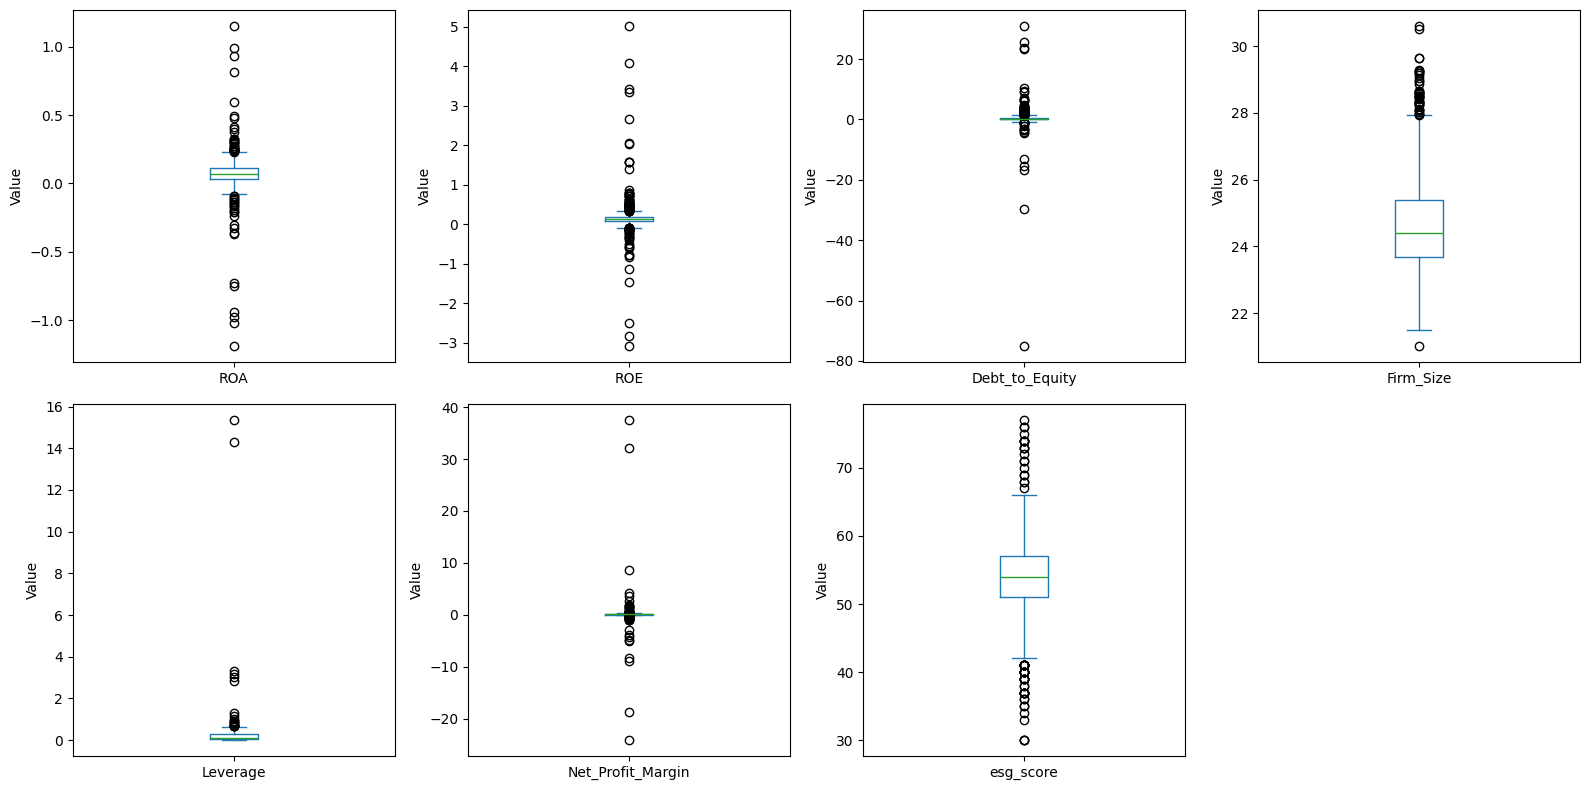

In [ ]:
# DESCRIPTIVE STATISTICS - INDIVIDUAL BOXPLOTS WITH LABELS
columns_to_plot = ["ROA", "ROE", "Debt_to_Equity", "Firm_Size", "Leverage", "Net_Profit_Margin", "esg_score"]

diagram1 = data1[columns_to_plot].plot(kind="box", subplots=True, layout=(2, 4), figsize=(16, 8))

diagram1 = list(diagram1)

for i in range(len(columns_to_plot)):
    diagram1[i].set_ylabel("Value")

plt.tight_layout()
plt.show()

# Skewness Analysis

In [ ]:
# SKEWNESS CHECK
# skewness close to 0 means the variable is roughly balanced
# skewness far from 0 (above 1 or below -1) means the variable
# has a long tail on one side, which can affect Linear Regression

data1[["ROA", "ROE", "Debt_to_Equity", "Firm_Size", "Leverage", "Net_Profit_Margin", "esg_score"]].skew()


,0
ROA,-1.839086
ROE,4.793989
Debt_to_Equity,-12.997020
Firm_Size,0.872426
Leverage,21.632431
Net_Profit_Margin,10.444659
esg_score,-0.064154


# Outlier Identification

In [ ]:
# checking specific companies causing extreme skewness
data1[data1["Debt_to_Equity"] < -50]

,company_name,company_clean_name,sector,yfinance_ticker,financial_year,fiscal_year_end,esg_score,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
351,Jyoti Structures Limited,JYOTI STRUCTURES LIMITED,Heavy Electrical Equipment,JYOTISTRUC.NS,FY2023,2024-03-31,36,0.012333,-1.12955,-75.003523,23.876049,0.81891,0.065925


In [ ]:
data1[data1['Net_Profit_Margin'] > 1]

,company_name,company_clean_name,sector,yfinance_ticker,financial_year,fiscal_year_end,esg_score,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
25,Alembic Limited,ALEMBIC LIMITED,Real Estate,ALEMBICLTD.NS,FY2023,2024-03-31,50,0.115348,0.122906,0.004186,23.871192,0.003929,1.825823
97,Bombay Dyeing & Manufacturing Company Limited,BOMBAY DYEING & MANUFACTURING COMPANY LIMITED,Textiles,BOMDYEING.NS,FY2023,2024-03-31,50,1.151584,1.573475,0.000000,23.966053,0.000000,1.768220
397,MMTC Limited,MMTC LIMITED,Trading,MMTC.NS,FY2023,2024-03-31,43,0.056793,0.121356,0.002943,24.244874,0.001377,37.461988
530,Rattanindia Power Limited,RATTANINDIA POWER LIMITED,Power Thermal,RTNPOWER.NS,FY2023,2024-03-31,48,0.930071,2.038725,1.016960,25.284032,0.463939,2.644694
531,Raymond Limited,RAYMOND LIMITED,Textiles,RAYMOND.NS,FY2023,2024-03-31,51,0.124327,0.354696,0.905656,25.604016,0.317447,1.761893
696,Valor Estate Limited,VALOR ESTATE LIMITED,Real Estate,DBREALTY.NS,FY2023,2024-03-31,45,0.143989,0.263092,0.408199,25.241029,0.223405,3.690879
753,Alembic Limited,ALEMBIC LIMITED,Real Estate,ALEMBICLTD.NS,FY2024,2025-03-31,51,0.124122,0.132848,0.006178,23.943342,0.005772,1.471138
784,Aster DM Healthcare Limited,ASTER DM HEALTHCARE LIMITED,Hospital,ASTERDM.NS,FY2024,2025-03-31,57,0.814036,1.568763,0.588602,24.913887,0.305427,1.299476
932,GOCL Corporation Limited,GOCL CORPORATION LIMITED,Chemicals (Explosives),GOCLCORP.NS,FY2024,2025-03-31,37,0.050508,0.099608,0.707503,24.160107,0.358752,8.632256
1125,MMTC Limited,MMTC LIMITED,Trading,MMTC.NS,FY2024,2025-03-31,45,0.024905,0.050894,0.001433,24.272438,0.000701,32.204461


In [ ]:
data1[data1["Leverage"] > 2]

,company_name,company_clean_name,sector,yfinance_ticker,financial_year,fiscal_year_end,esg_score,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
31,Alok Industries Limited,ALOK INDUSTRIES LIMITED,Textiles,ALOKINDS.NS,FY2023,2024-03-31,47,-0.114330,0.042821,-1.136405,25.028253,3.034144,-0.156197
403,Mahanagar Telephone Nigam Limited,MAHANAGAR TELEPHONE NIGAM LIMITED,Telecom,MTNL.NS,FY2023,2024-03-31,47,-0.304882,0.138196,-1.274790,25.397714,2.812384,-4.304069
637,Tata Teleservices (Maharashtra) Limited,TATA TELESERVICES MAHARASHTRA LIMITED,Telecom,TTML.NS,FY2023,2024-03-31,55,-0.939900,0.063805,-1.041251,23.293578,15.338419,-1.035016
759,Alok Industries Limited,ALOK INDUSTRIES LIMITED,Textiles & Apparels,ALOKINDS.NS,FY2024,2025-03-31,49,-0.121314,0.039575,-1.086772,24.932407,3.331451,-0.225062
1132,Mahanagar Telephone Nigam Limited,MAHANAGAR TELEPHONE NIGAM LIMITED,Telecommunication - Cellular & Fixed line serv...,MTNL.NS,FY2024,2025-03-31,41,-0.325404,0.123619,-1.205150,25.350817,3.172340,-2.945875
1365,Tata Teleservices (Maharashtra) Limited,TATA TELESERVICES MAHARASHTRA LIMITED,Telecommunication - Cellular & Fixed line serv...,TTML.NS,FY2024,2025-03-31,54,-0.978164,0.065166,-0.952391,23.291126,14.295684,-0.980314


In [ ]:
data1[data1["ROE"] > 1]

,company_name,company_clean_name,sector,yfinance_ticker,financial_year,fiscal_year_end,esg_score,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
69,BF Utilities Limited,BF UTILITIES LIMITED,Road Assets - Toll Annuity Hybrid-Annuity,BFUTILITIE.NS,FY2023,2024-03-31,39,0.060709,2.661838,23.441303,23.912651,0.534630,0.152123
97,Bombay Dyeing & Manufacturing Company Limited,BOMBAY DYEING & MANUFACTURING COMPANY LIMITED,Textiles,BOMDYEING.NS,FY2023,2024-03-31,50,1.151584,1.573475,0.000000,23.966053,0.000000,1.768220
322,Interglobe Aviation Limited,INTERGLOBE AVIATION LIMITED,Airlines,INDIGO.NS,FY2023,2024-03-31,56,0.099393,4.093413,25.684999,27.435304,0.623660,0.121277
530,Rattanindia Power Limited,RATTANINDIA POWER LIMITED,Power Thermal,RTNPOWER.NS,FY2023,2024-03-31,48,0.930071,2.038725,1.016960,25.284032,0.463939,2.644694
549,SEL Manufacturing Company Limited,SEL MANUFACTURING COMPANY LIMITED,Textiles,SELMC.NS,FY2023,2024-03-31,30,-0.182821,3.421825,-16.668692,23.079792,0.890573,-0.548783
554,Sadbhav Engineering Limited,SADBHAV ENGINEERING LIMITED,Construction EPC,SADBHAV.NS,FY2023,2024-03-31,30,-0.089383,5.025079,-29.786782,24.978771,0.529830,-0.335940
784,Aster DM Healthcare Limited,ASTER DM HEALTHCARE LIMITED,Hospital,ASTERDM.NS,FY2024,2025-03-31,57,0.814036,1.568763,0.588602,24.913887,0.305427,1.299476
1198,Omaxe Limited,OMAXE LIMITED,Real Estate,OMAXE.NS,FY2024,2025-03-31,40,-0.046110,3.344221,-3.211914,25.725695,0.044286,-0.439465
1259,Raymond Limited,RAYMOND LIMITED,Textiles & Apparels,RAYMOND.NS,FY2024,2025-03-31,53,0.988991,2.053572,0.199220,25.069187,0.095944,4.101250
1325,Strides Pharma Science Limited,STRIDES PHARMA SCIENCE LIMITED,Pharmaceuticals,STAR.NS,FY2024,2025-03-31,57,0.594085,1.408187,0.736582,24.825698,0.310749,0.818241


# Correlation Matrix

In [ ]:
# CORRELATION MATRIX
data1[["ROA", "ROE", "Debt_to_Equity", "Firm_Size", "Leverage", "Net_Profit_Margin", "esg_score"]].corr()

,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin,esg_score
ROA,1.000000,0.359986,-0.000966,0.002515,-0.447282,0.270400,0.193390
ROE,0.359986,1.000000,0.013052,0.053247,0.002365,0.104186,-0.008655
Debt_to_Equity,-0.000966,0.013052,1.000000,0.098992,0.004335,0.007882,0.100264
Firm_Size,0.002515,0.053247,0.098992,1.000000,0.042616,0.050471,0.193096
Leverage,-0.447282,0.002365,0.004335,0.042616,1.000000,-0.052687,-0.050865
Net_Profit_Margin,0.270400,0.104186,0.007882,0.050471,-0.052687,1.000000,-0.016837
esg_score,0.193390,-0.008655,0.100264,0.193096,-0.050865,-0.016837,1.000000


## Correlation Heatmap

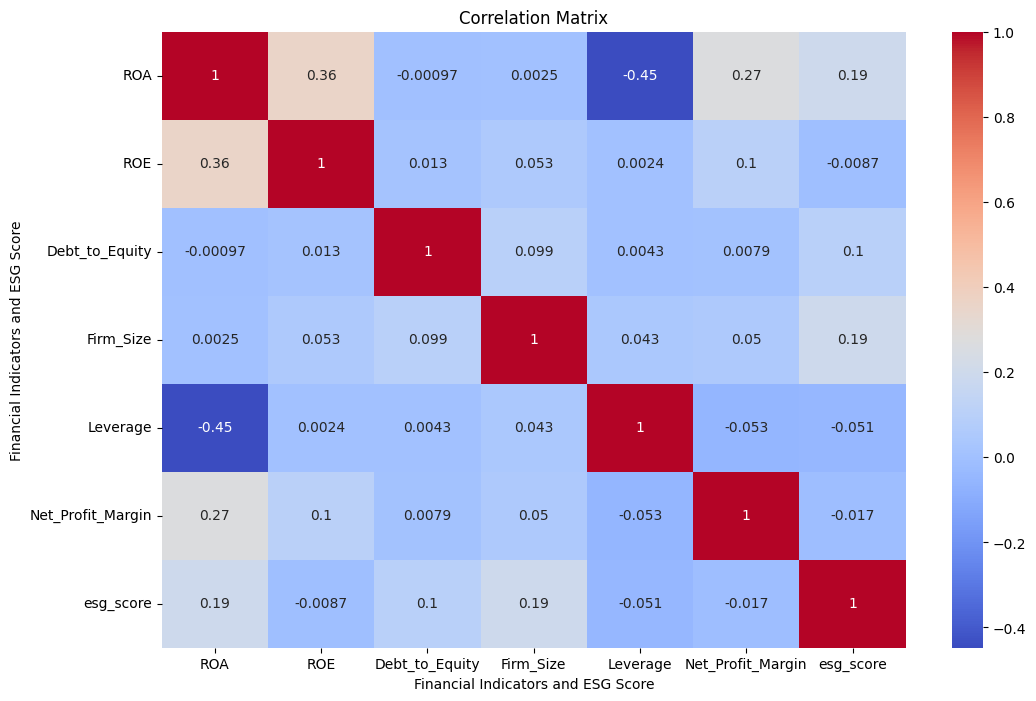

In [ ]:

heatmap_data = data1[["ROA","ROE","Debt_to_Equity","Firm_Size","Leverage","Net_Profit_Margin","esg_score"]]

# Draw the correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.xlabel("Financial Indicators and ESG Score")
plt.ylabel("Financial Indicators and ESG Score")
plt.show()

# VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x_vif = data1[["ROA","ROE","Debt_to_Equity","Firm_Size","Leverage","Net_Profit_Margin"]]

vif_table = pd.DataFrame()
vif_table["feature"] = x_vif.columns

vif_table["VIF"] = [variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])]

vif_table

,feature,VIF
0,ROA,2.312194
1,ROE,1.456264
2,Debt_to_Equity,1.023503
3,Firm_Size,2.028487
4,Leverage,1.460718
5,Net_Profit_Margin,1.089329


# Define Features (X) and Target (y)

In [ ]:
y = data1["esg_score"]
x = data1.drop(["esg_score", "company_name","yfinance_ticker","company_clean_name", "sector", "financial_year", "fiscal_year_end"], axis=1)
print(x.shape)
print(y.shape)

(1456, 6)
(1456,)


In [ ]:
x.head()

,ROA,ROE,Debt_to_Equity,Firm_Size,Leverage,Net_Profit_Margin
0,0.179611,0.271748,0.008467,24.203959,0.005596,0.139344
1,0.099921,0.142999,0.021732,26.177207,0.015185,0.119289
2,0.135394,0.170662,0.126626,22.438957,0.100459,0.150397
3,0.074867,0.138502,0.341956,24.236890,0.184844,0.104717
4,0.151507,0.170564,0.069252,25.040109,0.061514,0.237394


## Train-Test Split

In [ ]:
# DATA SPLITTING FOR TWO YEARS

feature_cols = ["ROA","ROE","Debt_to_Equity","Firm_Size","Leverage","Net_Profit_Margin"]

# FY2023 is the training data
train = data1[data1["financial_year"] == "FY2023"]

# FY2024 is the testing data
test = data1[data1["financial_year"] == "FY2024"]

# Select the financial features
x_train = train[feature_cols]
x_test = test[feature_cols]

# Select the ESG score
y_train = train["esg_score"]
y_test = test["esg_score"]


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit only on FY2023 training data
x_train = scaler.fit_transform(x_train)
# Use the same scaler on FY2024 testing data
x_test = scaler.transform(x_test)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(728, 6)
(728, 6)
(728,)
(728,)


# Fiscal Year Distribution Check

In [ ]:
data1["fiscal_year_end"].value_counts()

,count
fiscal_year_end,
2024-03-31,728
2025-03-31,728


# Baseline Comparisons

## Mean Baseline

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Calculate the mean (average) ESG score from the training set
mean_score = y_train.mean()

# 2. Create an array of predictions for the test set where every value is that same mean score
y_pred_mean = np.full(shape=len(y_test), fill_value=mean_score)

# 3. Evaluate the Mean Baseline model using R2, RMSE, and MAE
R2_mean = r2_score(y_test, y_pred_mean)
RMSE_mean = np.sqrt(mean_squared_error(y_test, y_pred_mean))
MAE_mean = mean_absolute_error(y_test, y_pred_mean)

# 4. Print the final performance results
print("Mean Baseline Performance")
print("R2 =", round(R2_mean, 4))
print("RMSE =", round(RMSE_mean, 4))
print("MAE =", round(MAE_mean, 4))

Mean Baseline Performance
R2 = -0.0017
RMSE = 5.7705
MAE = 4.2881


## Previous-Year basline

In [ ]:
# PREVIOUS-YEAR ESG BASELINE

# Getting each company's FY2023 ESG score
previous_year_scores = train.set_index("company_clean_name")["esg_score"]

# Using the FY2023 score to predict the FY2024 score
y_pred_previous = test["company_clean_name"].map(previous_year_scores)

# Calculate the results
R2_previous = r2_score(y_test, y_pred_previous)
RMSE_previous = np.sqrt(mean_squared_error(y_test, y_pred_previous))
MAE_previous = mean_absolute_error(y_test, y_pred_previous)

# Print the results
print("Previous-Year Baseline")
print("R2 =", round(R2_previous, 4))
print("RMSE =", round(RMSE_previous, 4))
print("MAE =", round(MAE_previous, 4))

Previous-Year Baseline
R2 = 0.8066
RMSE = 2.5355
MAE = 1.8599


# Model 1 - Linear Regression

In [ ]:

# LINEAR REGRESSION (BASELINE)

# MODELLING
# Linear Regression is the simplest possible model, assuming a straight line relationship between financial indicators and ESG scores. It is included as a baseline so we can test whether the ML models actually add value over a simple statistical approach

from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()
LR_model.fit(x_train, y_train)
y_pred_lr = LR_model.predict(x_test)

# EVALUATION
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

R2_LR = r2_score(y_test, y_pred_lr)
RMSE_LR = np.sqrt(mean_squared_error(y_test, y_pred_lr))
MAE_LR = mean_absolute_error(y_test, y_pred_lr)
print("R2 =", round(R2_LR, 4))
print("RMSE =", round(RMSE_LR, 4))
print("MAE =", round(MAE_LR, 4))

R2 = 0.0839
RMSE = 5.5185
MAE = 4.1737


# Random Forest

## Initial Random Forest

In [ ]:

# RANDOM FOREST REGRESSOR

# Initial Random Forest
# MODELLING
# Random Forest builds many decision trees independently and averages their predictions, reducing overfitting compared to a single decision tree and capturing non-linear relationships

from sklearn.ensemble import RandomForestRegressor

RF_Regressor1 = RandomForestRegressor(n_estimators=500, max_features="sqrt", min_samples_split=5, min_samples_leaf=2, max_depth=None, random_state=42)
RF_Regressor1.fit(x_train, y_train)
y_pred_rf = RF_Regressor1.predict(x_test)

# EVALUATION
R2_RF = r2_score(y_test, y_pred_rf)
RMSE_RF = np.sqrt(mean_squared_error(y_test, y_pred_rf))
MAE_RF = mean_absolute_error(y_test, y_pred_rf)
print("R2 =", round(R2_RF, 4))
print("RMSE =", round(RMSE_RF, 4))
print("MAE =", round(MAE_RF, 4))

R2 = 0.2791
RMSE = 4.8954
MAE = 3.8118


## Overfitting Check

In [ ]:
# check Random Forest performance on TRAINING data and test data
y_train_pred_rf_initial = RF_Regressor1.predict(x_train)
y_test_pred_rf_initial = RF_Regressor1.predict(x_test)

R2_RF_initial_train = r2_score(y_train, y_train_pred_rf_initial)
R2_RF_initial_test = r2_score(y_test, y_test_pred_rf_initial)

print("Initial Random Forest")
print("Training R2 =", round(R2_RF_initial_train, 4))
print("Test R2 =", round(R2_RF_initial_test, 4))

Initial Random Forest
Training R2 = 0.7509
Test R2 = 0.2791


## Grid-Search-Selected Random Forest

In [ ]:
# Grid-Search-Selected Random Forest
from sklearn.model_selection import GridSearchCV
RF_Regressor2 = RandomForestRegressor(max_features="sqrt", random_state=42)

rf_params = {"n_estimators": [100, 300, 500],
            "max_features": ["sqrt"],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4, 6],
            "max_depth": [None, 5, 10, 20]}

# cross-validation
grid_search_rf = GridSearchCV(estimator=RF_Regressor2, param_grid=rf_params, scoring="r2", cv=5, n_jobs=-1)
grid_search_rf.fit(x_train, y_train)

# Show the best settings
best_rf_params = grid_search_rf.best_params_
print("Best parameters:", best_rf_params)

# Select the best model
best_rf = grid_search_rf.best_estimator_

Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
y_pred_rf_tuned = best_rf.predict(x_test)
R2_RF_tuned = r2_score(y_test, y_pred_rf_tuned)

RMSE_RF_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
MAE_RF_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("R2 =", round(R2_RF_tuned, 4))
print("RMSE =", round(RMSE_RF_tuned, 4))
print("MAE =", round(MAE_RF_tuned, 4))

R2 = 0.2636
RMSE = 4.9476
MAE = 3.8378


## Overfitting Check

In [ ]:
# check performance on TRAINING data and test data
y_train_pred_rf_tuned = best_rf.predict(x_train)
y_test_pred_rf_tuned = best_rf.predict(x_test)
R2_RF_tuned_train = r2_score(y_train, y_train_pred_rf_tuned)
R2_RF_tuned_test = r2_score(y_test, y_test_pred_rf_tuned)

print("GridSearch_selected Random Forest")
print("Training R2 =", round(R2_RF_tuned_train, 4))
print("Test R2 =", round(R2_RF_tuned_test, 4))

GridSearch_selected Random Forest
Training R2 = 0.6442
Test R2 = 0.2636


# GRADIENT BOOSTING

## Initial Gradient Boosting Machine

In [ ]:

# GRADIENT BOOSTING MACHINE REGRESSOR

# Initial GBM
# MODELLING
# GBM builds trees one at a time sequentially, where each new tree corrects the errors made by the previous tree. This reduces bias rather than variance, making it complementary to Random Forest

from sklearn.ensemble import GradientBoostingRegressor

GBM_Regressor1 = GradientBoostingRegressor(n_estimators=500,learning_rate=0.05,max_depth=4,min_samples_split=5,min_samples_leaf=2,random_state=42)
GBM_Regressor1.fit(x_train, y_train)
y_pred_gbm = GBM_Regressor1.predict(x_test)

# EVALUATION
R2_GBM = r2_score(y_test, y_pred_gbm)
RMSE_GBM = np.sqrt(mean_squared_error(y_test, y_pred_gbm))
MAE_GBM = mean_absolute_error(y_test, y_pred_gbm)
print("R2 =", round(R2_GBM, 4))
print("RMSE =", round(RMSE_GBM, 4))
print("MAE =", round(MAE_GBM, 4))

R2 = 0.2125
RMSE = 5.1167
MAE = 3.9607


## Overfitting Check

In [ ]:
# check performance on TRAINING data and test data
y_train_pred_gbm_initial = GBM_Regressor1.predict(x_train)
y_test_pred_gbm_initial = GBM_Regressor1.predict(x_test)

R2_GBM_initial_train = r2_score(y_train, y_train_pred_gbm_initial)
R2_GBM_initial_test = r2_score(y_test, y_test_pred_gbm_initial)

print("Initial GBM")
print("Training R2 =", round(R2_GBM_initial_train, 4))
print("Test R2 =", round(R2_GBM_initial_test, 4))

Initial GBM
Training R2 = 0.9188
Test R2 = 0.2125


## GridSearch Selected Gradient Boosting

In [ ]:
# METHOD 2
from sklearn.model_selection import GridSearchCV
# Create a Gradient Boosting Machine Regressor

GBM_Regressor2 = GradientBoostingRegressor(random_state=42)

gbm_params = {"n_estimators": [100, 300, 500],
              "learning_rate": [0.01, 0.05, 0.1],
              "max_depth": [3, 4, 5],
              "min_samples_split": [2, 5, 10],
              "min_samples_leaf": [1, 2, 4]}

grid_search_gbm = GridSearchCV(estimator=GBM_Regressor2, param_grid=gbm_params, scoring="r2", cv=5)
grid_search_gbm.fit(x_train, y_train)

best_gbm_params = grid_search_gbm.best_params_
print("Best parameters:", best_gbm_params)

best_gbm = grid_search_gbm.best_estimator_

Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


In [ ]:
y_pred_gbm_tuned = best_gbm.predict(x_test)
R2_GBM_tuned = r2_score(y_test, y_pred_gbm_tuned)
RMSE_GBM_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gbm_tuned))
MAE_GBM_tuned = mean_absolute_error(y_test, y_pred_gbm_tuned)
print("R2 =", round(R2_GBM_tuned, 4))
print("RMSE =", round(RMSE_GBM_tuned, 4))
print("MAE =", round(MAE_GBM_tuned, 4))

R2 = 0.2358
RMSE = 5.0402
MAE = 3.8786


## Overfitting Check

In [ ]:
# check performance on TRAINING data and test data
y_train_pred_gbm_grid = best_gbm.predict(x_train)
y_test_pred_gbm_grid = best_gbm.predict(x_test)

R2_GBM_grid_train = r2_score(y_train, y_train_pred_gbm_grid)
R2_GBM_grid_test = r2_score(y_test, y_test_pred_gbm_grid)

print("Gridsearch_selected GBM")
print("Training R2 =", round(R2_GBM_grid_train, 4))
print("Test R2 =", round(R2_GBM_grid_test, 4))

Gridsearch_selected GBM
Training R2 = 0.5359
Test R2 = 0.2358


# Model comparison

In [ ]:

# FY2024 PERFORMANCE COMPARISON

print(f"{'Model':<40} {'R2':>10} {'RMSE':>10} {'MAE':>10}")
print("-" * 75)
print(f"{'Linear Regression':<40} {round(R2_LR,4):>9} {round(RMSE_LR,4):>10} {round(MAE_LR,4):>10}")
print(f"{'Initial Random Forest':<40} {round(R2_RF,4):>9} {round(RMSE_RF,4):>10} {round(MAE_RF,4):>10}")
print(f"{'Grid-Search-Selected Random Forest':<40} {round(R2_RF_tuned,4):>9} {round(RMSE_RF_tuned,4):>10} {round(MAE_RF_tuned,4):>10}")
print(f"{'Initial GBM':<40} {round(R2_GBM,4):>9} {round(RMSE_GBM,4):>10} {round(MAE_GBM,4):>10}")
print(f"{'Grid-Search-Selected GBM':<40} {round(R2_GBM_tuned,4):>9} {round(RMSE_GBM_tuned,4):>10} {round(MAE_GBM_tuned,4):>10}")
print(f"{'Mean Baseline':<40} {round(R2_mean,4):>9} {round(RMSE_mean,4):>10} {round(MAE_mean,4):>10}")
print(f"{'Previous-Year ESG Baseline':<40} {round(R2_previous,4):>9} {round(RMSE_previous,4):>10} {round(MAE_previous,4):>10}")

Model                                            R2       RMSE        MAE
---------------------------------------------------------------------------
Linear Regression                           0.0839     5.5185     4.1737
Initial Random Forest                       0.2791     4.8954     3.8118
Grid-Search-Selected Random Forest          0.2636     4.9476     3.8378
Initial GBM                                 0.2125     5.1167     3.9607
Grid-Search-Selected GBM                    0.2358     5.0402     3.8786
Mean Baseline                              -0.0017     5.7705     4.2881
Previous-Year ESG Baseline                  0.8066     2.5355     1.8599


## Actual vs Estimated ESG Scores Visual Comparison





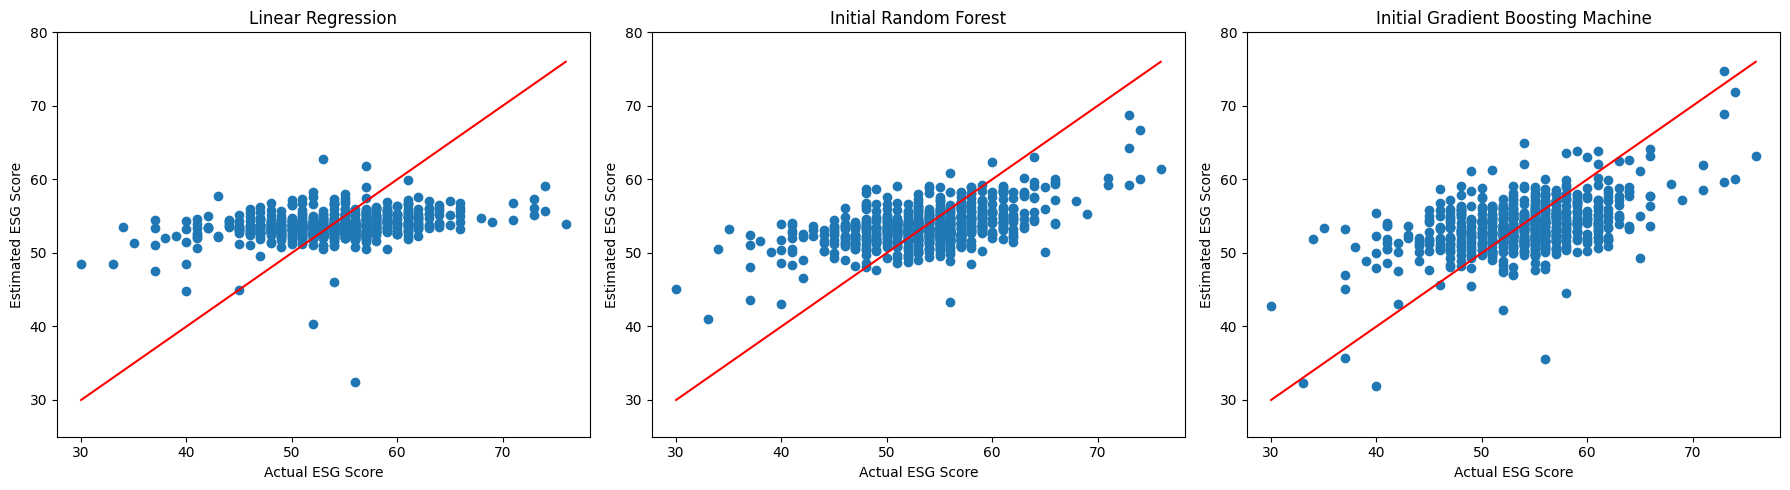

In [ ]:
# ACTUAL VS estimated - MODEL COMPARISON
fig, model = plt.subplots(1, 3, figsize=(18, 5))

model[0].scatter(y_test, y_pred_lr)
model[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
model[0].set_title("Linear Regression")
model[0].set_xlabel("Actual ESG Score")
model[0].set_ylabel("Estimated ESG Score")
model[0].set_ylim(25, 80)

model[1].scatter(y_test, y_pred_rf)
model[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
model[1].set_title("Initial Random Forest")
model[1].set_xlabel("Actual ESG Score")
model[1].set_ylabel("Estimated ESG Score")
model[1].set_ylim(25, 80)

model[2].scatter(y_test, y_pred_gbm)
model[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
model[2].set_title("Initial Gradient Boosting Machine")
model[2].set_xlabel("Actual ESG Score")
model[2].set_ylabel("Estimated ESG Score")
model[2].set_ylim(25, 80)

plt.tight_layout()
plt.show()

# SHAP analysis

In [ ]:
import shap

# The previous-year baseline performed best overall.
# However, it does not use financial indicators.
# Therefore, SHAP is applied to the best financial-indicator model.
final_model = RF_Regressor1
final_model_name = "Initial Random Forest"

print("SHAP analysis on the best financial-indicator model:", final_model_name)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(x_test)

shap_importance = DataFrame()
shap_importance["feature"] = feature_cols
shap_importance["mean_abs_shap"] = abs(shap_values).mean(axis=0)

shap_importance = shap_importance.sort_values("mean_abs_shap",ascending=False)

shap_importance

SHAP analysis on the best financial-indicator model: Initial Random Forest


,feature,mean_abs_shap
3,Firm_Size,0.963278
1,ROE,0.584443
0,ROA,0.562410
5,Net_Profit_Margin,0.424721
4,Leverage,0.322276
2,Debt_to_Equity,0.273697


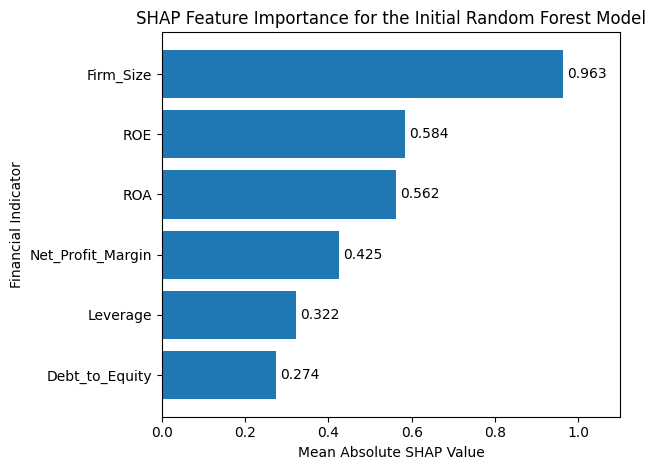

In [ ]:
bars = plt.barh(shap_importance["feature"], shap_importance["mean_abs_shap"])
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Financial Indicator")
plt.title("SHAP Feature Importance for the Initial Random Forest Model")
plt.bar_label(bars, fmt="%.3f", padding=3)
plt.xlim(0, 1.1)
plt.gca().invert_yaxis()   # puts the most important feature at the top
plt.tight_layout()
plt.show()

# Final Estimations by Company (FY2024)

In [ ]:

final_results = data1[data1["fiscal_year_end"] == "2025-03-31"][["company_name","financial_year", "fiscal_year_end", "esg_score"]].copy()
final_results["LR_estimated"] = y_pred_lr
final_results["RF_initial_estimated"] = y_pred_rf
final_results["RF_grid_search_selected_estimated"] = y_pred_rf_tuned
final_results["GBM_initial_estimated"] = y_pred_gbm
final_results["GBM_grid_search_selected_estimated"] = y_pred_gbm_tuned

final_results.head(15)

,company_name,financial_year,fiscal_year_end,esg_score,LR_estimated,RF_initial_estimated,RF_grid_search_selected_estimated,GBM_initial_estimated,GBM_grid_search_selected_estimated
728,3M India Limited,FY2024,2025-03-31,60,54.079831,56.591769,56.642199,55.285756,55.327426
729,ACC Limited,FY2024,2025-03-31,55,55.208945,57.023614,56.885274,58.971004,56.560905
730,ADF Foods Limited,FY2024,2025-03-31,49,52.316929,50.284317,52.269668,52.256521,52.739165
731,AGI Greenpac Limited,FY2024,2025-03-31,53,53.546538,51.723991,52.825293,50.049606,53.499822
732,AIA Engineering Limited,FY2024,2025-03-31,54,54.779249,52.806758,53.204232,51.927518,53.143929
733,APL Apollo Tubes Limited,FY2024,2025-03-31,59,54.218581,56.140015,55.482144,57.231908,56.210963
734,Aarti Drugs Limited,FY2024,2025-03-31,52,53.039003,51.667743,52.521593,52.335412,52.566465
735,Aarti Industries Limited,FY2024,2025-03-31,54,54.008237,51.526985,51.891166,51.852391,51.859048
736,Abbott India Limited,FY2024,2025-03-31,57,55.705752,56.207334,56.763200,55.453781,55.104776
737,Action Construction Equipment Limited,FY2024,2025-03-31,50,53.862281,55.981989,55.762215,56.272328,54.793628


# Prediction Range Check (0–100 Bounds)

In [ ]:
print("Inital RF estimations range:", round(y_pred_rf.min(), 2), "to", round(y_pred_rf.max(), 2))
print("Initial GBM estimations range:", round(y_pred_gbm.min(), 2), "to", round(y_pred_gbm.max(), 2))
print("LR estimations range:", round(y_pred_lr.min(), 2), "to", round(y_pred_lr.max(), 2))

Inital RF estimations range: 40.96 to 68.74
Initial GBM estimations range: 31.93 to 74.81
LR estimations range: 32.47 to 62.72


## R2 Scores Comparison

In [ ]:
# Compare R2 scores for all financial-indicator model specifications
print('R2 Score of Linear Regression:', round(R2_LR, 4))
print('R2 Score of Initial Random Forest:', round(R2_RF, 4))
print('R2 Score of Grid-Search-Selected Random Forest:', round(R2_RF_tuned, 4))
print('R2 Score of Initial Gradient Boosting Machine:', round(R2_GBM, 4))
print('R2 Score of Grid-Search-Selected Gradient Boosting Machine:', round(R2_GBM_tuned, 4))

R2 Score of Linear Regression: 0.0839
R2 Score of Initial Random Forest: 0.2791
R2 Score of Grid-Search-Selected Random Forest: 0.2636
R2 Score of Initial Gradient Boosting Machine: 0.2125
R2 Score of Grid-Search-Selected Gradient Boosting Machine: 0.2358


In [ ]:
# Find the best FINANCIAL-INDICATOR model using FY2024 R2

if R2_LR >= R2_RF and R2_LR >= R2_RF_tuned and R2_LR >= R2_GBM and R2_LR >= R2_GBM_tuned:
    best_model = LR_model
    best_score = R2_LR
    best_model_name = "Linear Regression"

elif R2_RF >= R2_RF_tuned and R2_RF >= R2_GBM and R2_RF >= R2_GBM_tuned:
    best_model = RF_Regressor1
    best_score = R2_RF
    best_model_name = "Initial Random Forest"

elif R2_RF_tuned >= R2_GBM and R2_RF_tuned >= R2_GBM_tuned:
    best_model = best_rf
    best_score = R2_RF_tuned
    best_model_name = "Grid-Search-Selected Random Forest"

elif R2_GBM >= R2_GBM_tuned:
    best_model = GBM_Regressor1
    best_score = R2_GBM
    best_model_name = "Initial Gradient Boosting Machine"

else:
    best_model = best_gbm
    best_score = R2_GBM_tuned
    best_model_name = "Grid-Search-Selected Gradient Boosting Machine"


print("Best financial-indicator model:", best_model_name)
print("FY2024 R2 =", round(best_score, 4),)
print("Strongest overall benchmark: Previous-Year ESG Baseline")
print("Previous-Year Baseline R2 =", round(R2_previous, 4))

Best financial-indicator model: Initial Random Forest
FY2024 R2 = 0.2791
Strongest overall benchmark: Previous-Year ESG Baseline
Previous-Year Baseline R2 = 0.8066


## Saving ML Models

In [ ]:
# Saving ML Models

import joblib

joblib.dump(best_model, "Best_Financial_Indicator_Model.pkl")
joblib.dump(scaler, "ESG_Scaler.pkl")

print("Best R2 Score:", round(best_score, 4))
print("Model and scaler saved successfully")

Best R2 Score: 0.2791
Model and scaler saved successfully


In [ ]:
# Load the saved best model
best_model = joblib.load("Best_Financial_Indicator_Model.pkl")
# Load the saved scaler
scaler = joblib.load("ESG_Scaler.pkl")